In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [3]:
data = pd.read_csv("antenna.csv")
data.head()

,Wm,W0m,dm,tm,rows,Xa,Ya,gain,vswr,bandwidth,s,pr,p0
0,2142.9,162.86,77.143,214.29,3.0,0.0,2142.9,2.799175,1.372040,110.6698,-16.090654,0.204248,0.483952
1,2142.9,162.86,77.143,214.29,3.0,3543.5,6964.3,2.817305,1.638103,120.7497,-12.328015,0.197374,0.464289
2,2142.9,162.86,351.430,214.29,5.0,8365.0,6964.3,2.941413,1.242714,123.6901,-19.313586,0.212885,0.490808
3,2142.9,162.86,351.430,214.29,3.0,8365.0,2142.9,2.844078,1.242587,122.4301,-19.317644,0.212405,0.496603
4,2142.9,162.86,351.430,214.29,3.0,8365.0,6964.3,2.812315,1.271176,124.3198,-18.459992,0.207997,0.489240


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Wm         572 non-null    float64
 1   W0m        572 non-null    float64
 2   dm         572 non-null    float64
 3   tm         572 non-null    float64
 4   rows       572 non-null    float64
 5   Xa         572 non-null    float64
 6   Ya         572 non-null    float64
 7   gain       572 non-null    float64
 8   vswr       572 non-null    float64
 9   bandwidth  509 non-null    float64
 10  s          572 non-null    float64
 11  pr         572 non-null    float64
 12  p0         572 non-null    float64
dtypes: float64(13)
memory usage: 58.2 KB


In [5]:
data.describe()

,Wm,W0m,dm,tm,rows,Xa,Ya,gain,vswr,bandwidth,s,pr,p0
count,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,509.000000,572.000000,572.000000,572.000000
mean,2244.048252,400.594178,275.425776,224.404825,4.097902,4063.246329,6947.469755,2.678568,2.094927,118.036075,-16.104948,0.192872,0.456955
std,691.578895,184.905214,150.901130,69.157890,1.443942,3287.862064,5136.193313,0.683242,1.914750,11.553491,7.897142,0.046994,0.089213
min,2142.900000,162.860000,77.143000,214.290000,3.000000,0.000000,2142.900000,-5.654378,1.041183,32.759900,-33.903172,0.037383,0.186297
25%,2142.900000,162.860000,77.143000,214.290000,3.000000,1132.800000,2142.900000,2.815006,1.187911,119.490100,-21.321550,0.200121,0.470947
50%,2142.900000,325.710000,214.290000,214.290000,3.000000,3543.500000,6964.300000,2.876220,1.438023,122.220100,-14.910812,0.211927,0.490360
75%,2142.900000,488.570000,351.430000,214.290000,5.000000,5954.300000,11786.000000,2.921877,1.725260,123.269800,-11.498286,0.214335,0.497100
max,6964.300000,651.430000,488.570000,696.430000,7.000000,10776.000000,16607.000000,3.238539,8.377999,124.740100,-2.083432,0.229538,0.499826


In [6]:
data.isnull().sum()

Wm            0
W0m           0
dm            0
tm            0
rows          0
Xa            0
Ya            0
gain          0
vswr          0
bandwidth    63
s             0
pr            0
p0            0
dtype: int64

In [7]:
data = data.dropna()

In [8]:
X = data[['Wm', 'W0m', 'dm', 'tm', 'rows', 'Xa', 'Ya', 'pr', 'p0']]
y = data[['gain', 'vswr', 'bandwidth', 's']]

In [9]:
# Escalamiento de valores
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Valor min después de la estandarización: {X_scaled.min()}")
print(f"Valor min después de la estandarización: {X_scaled.max()}")

Valor min después de la estandarización: -12.684853532209592
Valor min después de la estandarización: 7.453559924999299


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [11]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(4) # 4 salidas: 'gain', vswr, bandwidth, s
])

# Con esta función se pueden definir la estructura de la red, por ende definir la cantidad de capas y neuronas dentro de las mismas

c:\Users\Bremdows\anaconda3\envs\tensral\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Parámetros no entrenables indica la cantidad de parámetros que no se pueden entrenar
# Se aceptan casos de no entrenamiento: En el caso del transfer learning


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,852 (11.14 KB)

 Trainable params: 2,852 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Entrenamiento del modelo 

history = model.fit(X_train, y_train, epochs=500, batch_size=16, validation_split=0.2, verbose=True)

# batch_size = cantidad de datos a ingresar para el entrenamiento (16 datos al mismo tiempo), este valor es una potencia de 2, este valor también define el valor de cada iteración

# Por otro lado en DL si se hace uso del conjunto de validación (que normalmente no se utiliza en ML)

Epoch 1/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 3592.8093 - mae: 34.9597 - val_loss: 3542.9524 - val_mae: 34.9486
Epoch 2/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3513.9868 - mae: 34.4188 - val_loss: 3445.6780 - val_mae: 34.2056
Epoch 3/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3393.0876 - mae: 33.4368 - val_loss: 3292.7131 - val_mae: 32.9515
Epoch 4/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3205.8301 - mae: 32.0537 - val_loss: 3066.5679 - val_mae: 31.6207
Epoch 5/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2937.5454 - mae: 30.6940 - val_loss: 2746.1418 - val_mae: 29.7761
Epoch 6/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2567.0601 - mae: 28.3246 - val_loss: 2331.1082 - val_mae: 26.9108
Epoch 7/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2100.8860 - mae: 25.0362 - val_loss: 1825.0839 - val_mae: 23.2425
Epoch 8/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1576.0533 - mae: 21.2090 - val_loss: 1296.6257 - val_mae: 

In [14]:
# Metricas del módelo para su evaluación
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss} Test MAE: {test_mae}")

# Estos valores son necesarios para realizar una comparación con los modelos de ML para determinar cual es el más optimo

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 6.0770 - mae: 0.8447
Test Loss: 6.076993465423584 Test MAE: 0.8446913361549377


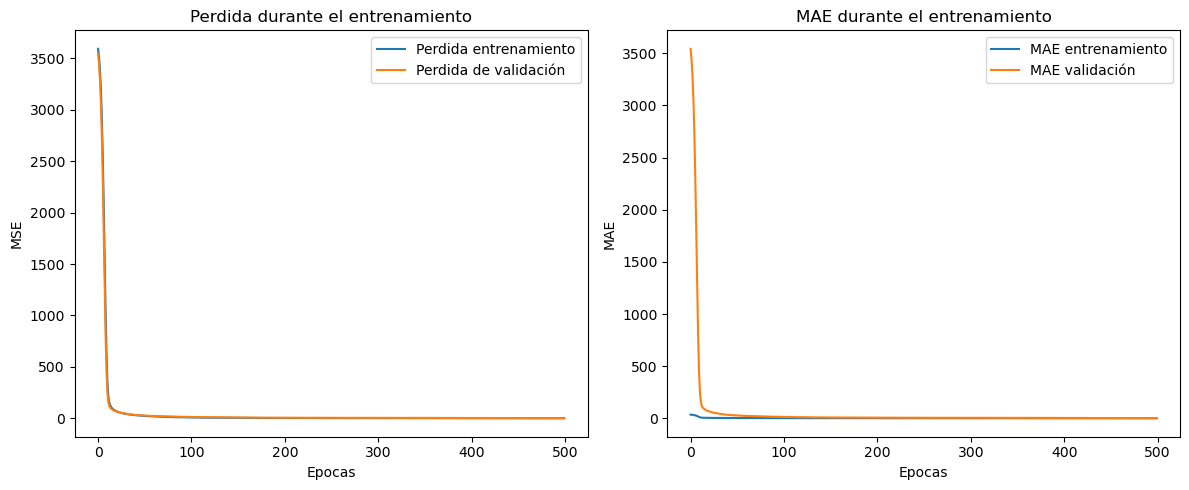

In [15]:
# Graficos de entrenamiento
plt.figure(figsize=(12, 5))

# Perdida MSE
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Perdida entrenamiento')
plt.plot(history.history['val_loss'], label='Perdida de validación')
plt.title('Perdida durante el entrenamiento')
plt.xlabel('Epocas')
plt.ylabel('MSE')
plt.legend()

# MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='MAE entrenamiento')
plt.plot(history.history['val_loss'], label='MAE validación')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Epocas')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()


In [16]:
y_pred = model.predict(X_test)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[  2.9959052 ,   1.8007333 , 112.42293   , -11.434817  ],
       [  2.9897375 ,   1.1584923 , 125.0087    , -21.741703  ],
       [  2.8614662 ,   0.94613177, 122.72183   , -26.310688  ],
       [  2.8903594 ,   1.2802172 , 123.476494  , -17.809414  ],
       [  3.0321915 ,   1.3595245 , 122.85523   , -20.162155  ],
       [  2.8216236 ,   1.2117723 , 113.624725  , -15.285753  ],
       [  2.6363823 ,   1.9464321 , 110.64048   , -12.494648  ],
       [  3.0410514 ,   1.3926871 , 124.543816  , -14.449613  ],
       [  2.9266114 ,   1.4431691 , 122.90654   , -13.924941  ],
       [  2.826089  ,   1.9465697 , 103.42355   , -10.063191  ],
       [  2.953693  ,   1.6041293 , 121.627075  , -12.782311  ],
       [  3.1087756 ,   1.7724185 , 118.59907   , -11.522523  ],
       [  2.906904  ,   1.3814571 , 121.687706  , -15.138543  ],
       [  2.894294  ,   1.5384192 , 121.3103    , -12.195346  ],
       [  2.9096103 ,   1.5708232 , 121.310234  , -12.581411  ],
       [  2.8641236 ,   1

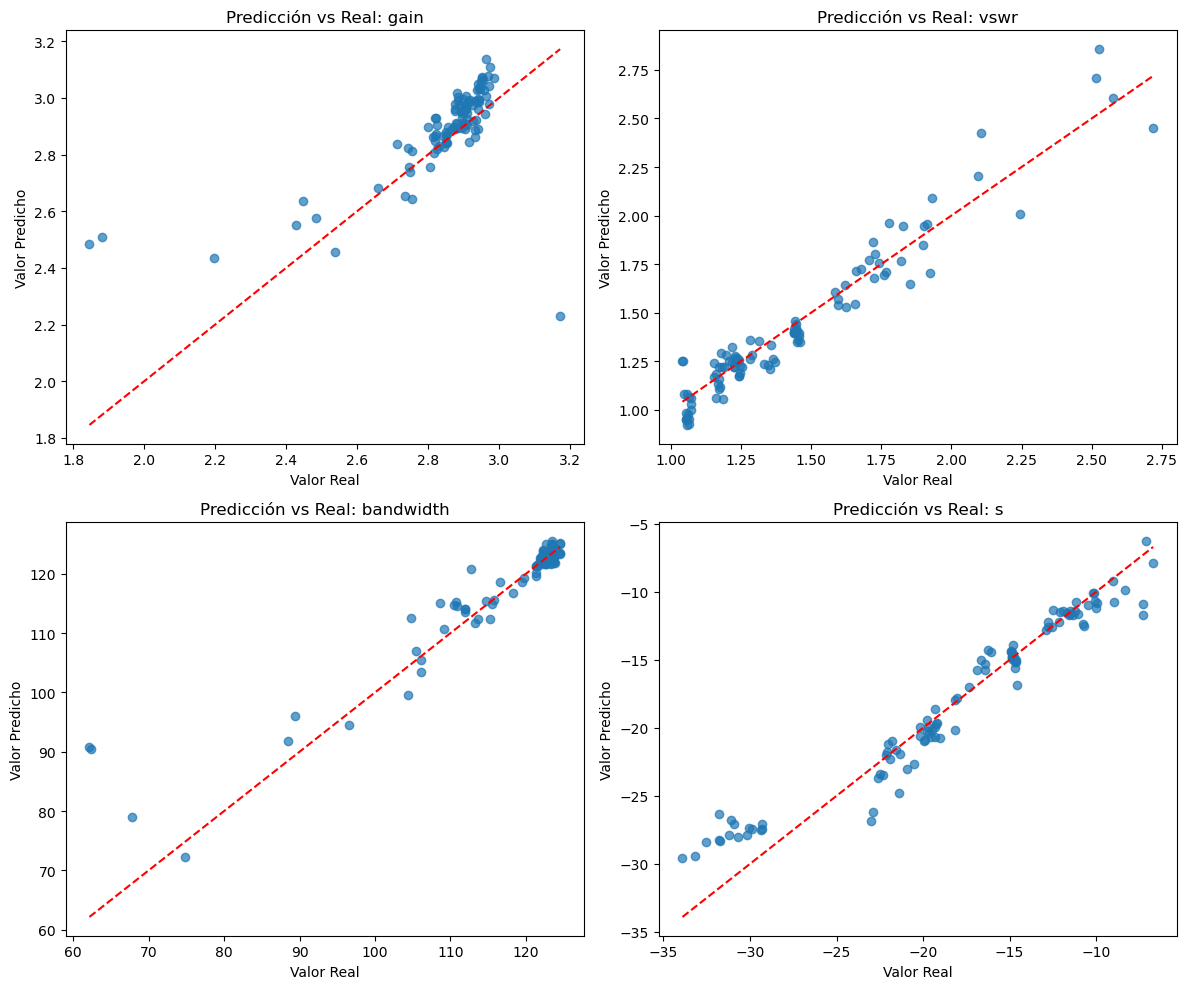

In [19]:
# Visualización de predicciones vs reales
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
targets = ['gain', 'vswr', 'bandwidth', 's']

for i, ax in enumerate(axs.flatten()) :
    ax.scatter(y_test.iloc[:, i], y_pred[:, i], alpha=0.7)
    ax.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
            [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 'r--')
    ax.set_title(f"Predicción vs Real: {targets[i]}")
    ax.set_xlabel('Valor Real')
    ax.set_ylabel('Valor Predicho')

plt.tight_layout()

In [21]:
model.save('rna_antena.keras')

In [ ]:
# Recomendaciones
"""
    Despues de un entrenamiento reiniciar la memoría CPU o GPU es de vital importancia para resguardar recursos y evitar daños o un consumo excesivo de los tiempos limite en servicios que prestan procesamiento (colab), esto se puede hacer mediante el reinicio de la sesióna en jupyter
"""